In [8]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
model_path = ('/content/drive/MyDrive/Googll Colab/datasetPandu/hasil/VGGNetUAS.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1/1 [==============================] - 0s 267ms/step
Image: /content/drive/MyDrive/Googll Colab/datasetPandu/testing/boots 102.jpg
Predicted class: boots
Confidence: 100.00%



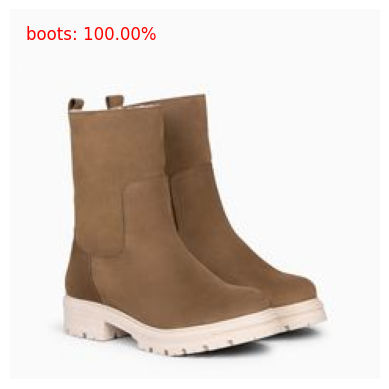

1/1 [==============================] - 0s 194ms/step
Image: /content/drive/MyDrive/Googll Colab/datasetPandu/testing/boots 103.jpg
Predicted class: boots
Confidence: 100.00%



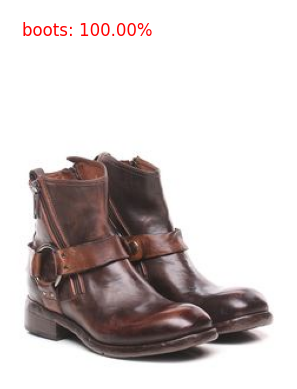

1/1 [==============================] - 0s 190ms/step
Image: /content/drive/MyDrive/Googll Colab/datasetPandu/testing/boots 104.jpg
Predicted class: boots
Confidence: 100.00%



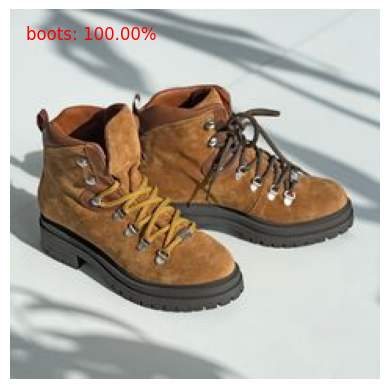

1/1 [==============================] - 0s 187ms/step
Image: /content/drive/MyDrive/Googll Colab/datasetPandu/testing/heels108.jpg
Predicted class: heels
Confidence: 100.00%



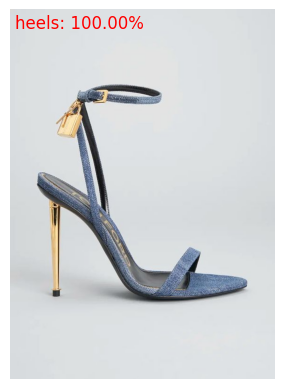

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_predict(image_paths, model, class_names):
    for image_path in image_paths:
        image = cv2.imread(image_path)

        if image is None:
            print(f"Error loading image: {image_path}")
            continue

        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        input_image = cv2.resize(rgb, (224, 224))
        input_image = input_image / 255.0
        input_image = np.expand_dims(input_image, axis=0)

        pred = model.predict(input_image)
        predicted_class_idx = np.argmax(pred)

        if 0 <= predicted_class_idx < len(class_names):
            predicted_class = class_names[predicted_class_idx]
            confidence = pred[0][predicted_class_idx] * 100

            print(f"Image: {image_path}")
            print(f"Predicted class: {predicted_class}")
            print(f"Confidence: {confidence:.2f}%")
            print()

            plt.imshow(rgb)
            plt.axis('off')
            text = f'{predicted_class}: {confidence:.2f}%'
            plt.text(10, 10, text, color='red', fontsize=12, ha='left', va='top')
            plt.show()

model = tf.keras.models.load_model(model_path)
image_paths = ['/content/drive/MyDrive/Googll Colab/datasetPandu/testing/boots 102.jpg',
               '/content/drive/MyDrive/Googll Colab/datasetPandu/testing/boots 103.jpg',
               '/content/drive/MyDrive/Googll Colab/datasetPandu/testing/boots 104.jpg',
               '/content/drive/MyDrive/Googll Colab/datasetPandu/testing/heels108.jpg'
              ]
class_names = ['boots', 'heels', 'sneaker']

process_and_predict(image_paths, model, class_names)
